In [71]:
import xarray as xr
import glob
from pathlib import Path
import toml
import numpy as np
import datetime
import os
import sys
import warnings
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import cmcrameri as cmc
warnings.filterwarnings('ignore')

### Explore TRAILS output data
1. Edit date of file
2. Edit path to config file
3. Open file and calculate the sum or air parcel identified as smoke (or dust influenced)
4. Call plotting function for visualization

In [ ]:

date = datetime.datetime(2023,5,15)
config_file = "../../config/config_leipzig.toml"

with open(config_file) as f:
    config = toml.load(f)
    
date_str = date.strftime("%Y%m%d")
station = config["station"]["short_name"]
output_path = config["output_dir"] +f"{date_str}_trails_{station}.nc"        

In [73]:
path_to_output_files = output_path
ds = xr.open_dataset(path_to_output_files)

In [74]:


# Sum of smoke identified particle positions
def mean_smoke_func(ds):
    # Assuming 'ds.type' is your xarray DataArray or numpy array
    data = ds.type[:, :, :, :].values  # Extract values as numpy array
    
    # Create a mask (True where value == 2, False otherwise)
    #mask = (data == 2)
    mask = (data == 1) | (data == 2) | (data == 3)
    # Apply mask: keep values == 2, set others to 0
    result = np.where(mask, 1, 0)  # Or use: data * mask
    
    sum_traj = np.nansum(result , axis = 0)
    
    
    mean_part = np.nansum(sum_traj, axis = 1)
    return mean_part

# Sum of dust flagged particle positions
def mean_dust_func(ds):
    # Assuming 'ds.type' is your xarray DataArray or numpy array
    data = ds.type[:, :, :, :].values  # Extract values as numpy array
    
    # Create a mask (True where value == 2, False otherwise)
    #mask = (data == 5)
    mask = (data == 4) | (data == 5) | (data == 6)
    # Apply mask: keep values == 2, set others to 0
    result = np.where(mask, 1, 0)  # Or use: data * mask
    
    sum_traj = np.nansum(result , axis = 0)
    
    
    mean_part = np.nansum(sum_traj, axis = 1)
    return mean_part



In [77]:
# Calculation of smoke and dust occurrence fraction is included 

def add_time_height(ax, ds, attribute = 'smoke', cmap = 'viridis', vmin = 0, vmax = 10,  fs = 12):
    #ax.set_title(f'{long_name}: BCO {date_str} ')
    data = ds
    data_times = (pd.to_datetime(matplotlib.dates.num2date(data.traj_end_time)) ).tz_localize(None)
    height =  np.linspace(config['height']['base']/1000,config['height']['top']/1000,ds.level.shape[0])
    
    if attribute == 'smoke':
       mean_smoke = mean_smoke_func(ds)
       sof = (mean_smoke)*100/(ds.position.shape[0]*ds.particle.shape[0])
       long_name = 'SOF (%)'
       cp = ax.pcolormesh(data_times, height, sof, vmin =vmin, vmax = vmax, cmap = cmap)
               
    if attribute == 'dust':
        mean_smoke = mean_dust_func(ds)
        dof = (mean_smoke)*100/(ds.position.shape[0]*ds.particle.shape[0]) 
        long_name = 'DOF (%)'
        cp = ax.pcolormesh(data_times, height, dof, vmin =vmin, vmax = vmax, cmap = cmap)
        
    #ax.grid(linestyle=':')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.25)
    cbar = plt.colorbar(cp, cax = cax,  ax=ax, fraction=0.05, pad=0.025)
    cbar.ax.set_ylabel(long_name, fontsize=fs)
    ax.set_xlabel('Time (UTC)')
    ax.set_ylabel('Height (km)')
    return ax, cbar

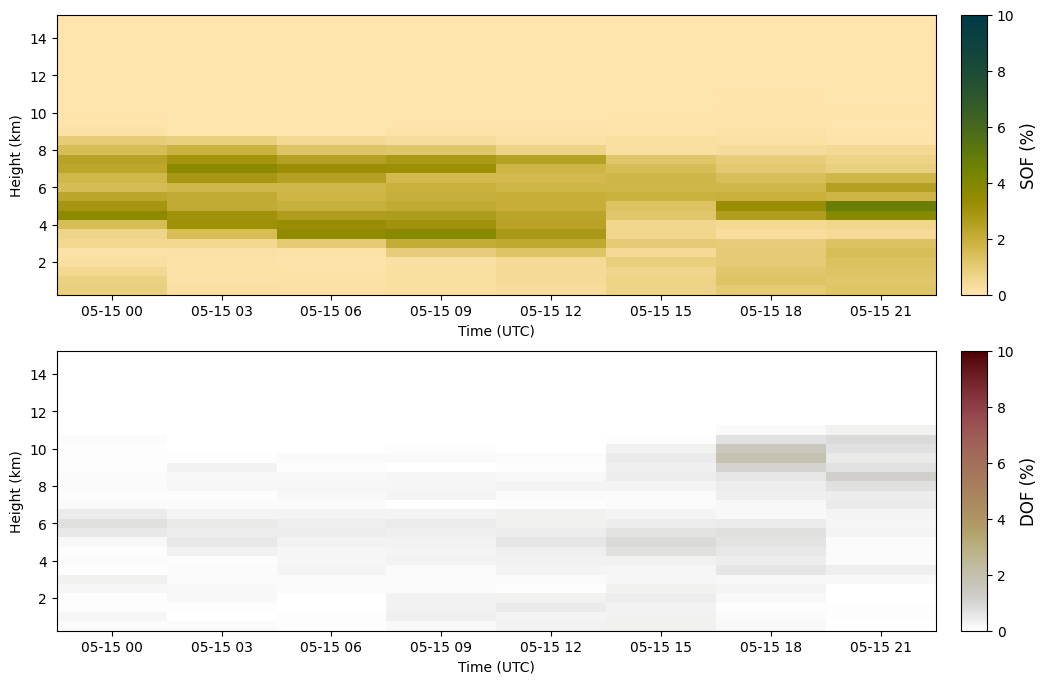

In [78]:


fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (12, 8))

ax1, cbar1 = add_time_height(ax1,  ds, attribute= 'smoke', cmap = cmc.cm.bamako_r, vmin = 0, vmax=10, fs = 12)

ax2, cbar2 = add_time_height(ax2,  ds, attribute= 'dust', cmap = cmc.cm.bilbao_r, vmin = 0, vmax=10, fs = 12)
